In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.integrate import solve_ivp
import itertools
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

df = pd.read_csv("GSE124821_data_1e8.csv")

# 2. Dynamically grep all columns containing 'quanTIseq'
quanTIseq_cols = [col for col in df.columns if 'quanTIseq' in col]

# 3. Define the masses used in the R script to reverse-engineer the fractions
masses_g = {
    "Dendritic_quanTIseq": 6e-10,
    "NK_quanTIseq": 6e-10,
    "T.CD8_quanTIseq": 2e-10,
    "Tregs_quanTIseq": 2e-10
}
total_cell_density = 1e8
cancer_cell_mass_g = 8e-9 # Based on C_M = 0.8 g/cm^3 at 1e8 cells

# 4. Reverse the R-script math to get the raw fractions back
df_fractions = pd.DataFrame()
for col in quanTIseq_cols:
    df_fractions[col] = df[col] / (masses_g[col] * total_cell_density)

# 5. Calculate Cancer Fraction (1 - sum of immune fractions)
cancer_fraction = (1.0 - df_fractions.sum(axis=1)).clip(lower=0)

# 6. Convert Cancer Fraction back into Mass Density (g/cm^3)
df['Cancer'] = cancer_fraction * total_cell_density * cancer_cell_mass_g

In [2]:
# Splitting Data and Extracting Series
# Train - validation split
df["strata"] = df["Mouse_treatment"] + "_" + df["Timepoint"]

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["strata"],
    random_state=SEED
)

# Extract time series averages
def extract_series(data):
    Cs, Ds, NKs, T8s, Trs = [], [], [], [], []
    for day in ["day3","day7"]:
        subset = data[data["Timepoint"] == day]
        # Make sure we grab our newly derived 'Cancer' column!
        Cs.append(subset["Cancer"].mean())
        Ds.append(subset["Dendritic_quanTIseq"].mean())
        NKs.append(subset["NK_quanTIseq"].mean())
        T8s.append(subset["T.CD8_quanTIseq"].mean())
        Trs.append(subset["Tregs_quanTIseq"].mean())

    return np.array(Cs), np.array(Ds), np.array(NKs), np.array(T8s), np.array(Trs)

C_train, D_train, NK_train, T8_train, Tr_train = extract_series(train_df)
C_val, D_val, NK_val, T8_val, Tr_val = extract_series(val_df)

# Initial conditions from day 3
y0_train = [C_train[0], D_train[0], NK_train[0], Tr_train[0], T8_train[0]]
y0_val   = [C_val[0], D_val[0], NK_val[0], Tr_val[0], T8_val[0]]

In [3]:
# ODE model
def cancer_ode(t,y,p):

    C,D,N,Tr,T8 = y

    dC = p["lambda_C"]*C*(1-C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD = p["lambda_DC_comb"]*C/(C+p["K_C"]) - p["d_D"]*D

    dN = (
        p["sigma_N"]
        - p["d_N"]*N
        - p["gamma_N"]*Tr*N
        + p["a_C"]*N*C/(1 + C/p["beta_1"] + N/p["beta_2"])
    )

    dTr = -p["d_Tr"]*Tr + p["lambda_Tr_comb"]*C/(p["K_C"]+C)

    dT8 = -p["d_T8"]*T8 + p["lambda_T8_comb"]*D/(p["K_D"]+D)/(1+Tr/p["K_Tr"])

    return [dC,dD,dN,dTr,dT8]

In [4]:
# baes_params
base_params = {
    "lambda_C":1.5,
    "C_M":0.8,
    "eta_8":328.55,
    "eta_N":300,
    "d_C":0.17,

    "lambda_DC_comb":8e-5,
    "K_C":0.4,
    "d_D":0.1,

    "sigma_N":5e-5,
    "d_N":0.1,
    "gamma_N":150,
    "a_C":0.5,
    "beta_1":0.4,
    "beta_2":2e-4,

    "d_Tr":0.2,
    "lambda_Tr_comb":2e-4,

    "d_T8":0.18,
    "lambda_T8_comb":0.00108,
    "K_Tr":2.5e-4,
    "K_D":4e-4
}

In [5]:
# Grid search parameter ranges
param_grid = {
    "lambda_DC_comb":[5e-4,7.5e-4,1e-3],
    "sigma_N":[5e-5,1e-4,2e-4,3e-4],
    "lambda_T8_comb":[1e-5,5e-5,1e-4],
    "d_T8":[0.075,0.1,0.18,0.25],
    "K_Tr":[1e-11,1e-8,1e-6],
    "d_N":[0.1,0.15,0.2]
}

In [6]:
# Relative Error metric & Grid Search Fitting
# Relative RMSE function
def rmse_rel(pred, true):
    # Dividing by 'true' makes the error relative (e.g. 10% off), 
    # preventing the massive cancer scale from dominating the optimizer.
    # We add 1e-9 to avoid dividing by absolute zero.
    return np.sqrt(np.mean(((pred - true) / (true + 1e-9))**2))

# Grid search on training set
best_params = None
best_error = np.inf

keys = param_grid.keys()
values = param_grid.values()

for combo in itertools.product(*values):
    params = base_params.copy()
    for k,v in zip(keys,combo):
        params[k] = v

    sol = solve_ivp(
        lambda t,y: cancer_ode(t,y,params),
        (0,7),
        y0_train,
        t_eval=[3,7]
    )

    pred = sol.y[:,1]
    
    # We are finally tracking all 5 cell lines, including Cancer!
    true = np.array([
        C_train[1],
        D_train[1],
        NK_train[1],
        Tr_train[1],
        T8_train[1]
    ])

    error = rmse_rel(pred, true)

    if error < best_error:
        best_error = error
        best_params = params.copy()

print(f"Best Relative Error: {best_error:.4f}")

Best Relative Error: 0.4293


In [7]:
def find_jacobian(p,y):
    C = y[0]
    D = y[1]
    N = y[2]
    Tr = y[3]
    T8 = y[4]
    
    lambda_C       = p['lambda_C']
    C_M            = p['C_M']
    eta_8          = p['eta_8']
    eta_N          = p['eta_N']
    d_C            = p['d_C']
    lambda_DC_comb = p['lambda_DC_comb']
    K_C            = p['K_C']
    d_D            = p['d_D']
    sigma_N        = p['sigma_N']
    d_N            = p['d_N']
    gamma_N        = p['gamma_N']
    a_C            = p['a_C']
    beta_1         = p['beta_1']
    beta_2         = p['beta_2']
    d_Tr           = p['d_Tr']
    lambda_Tr_comb = p['lambda_Tr_comb']
    d_T8           = p['d_T8']
    lambda_T8_comb = p['lambda_T8_comb']
    K_Tr           = p['K_Tr']
    K_D            = p['K_D']

    # Initialize a 5x5 Jacobian matrix with zeros
    J = np.zeros((5, 5))

    # ---------------------------------------------------------------------
    # PARTIAL DERIVATIVES
    # Replace the "0.0" placeholders below with your actual partial derivatives.
    # f0, f1, f2, f3, f4 correspond to the equations for C, D, N, Tr, T8.
    # ---------------------------------------------------------------------

    # Row 0: Derivatives of the Cancer cell equation (f0)
    J[0, 0] = lambda_C - d_C # df0 / dC
    J[0, 1] = 0.0 # df0 / dD
    J[0, 2] = -eta_N*C # df0 / dN
    J[0, 3] = 0.0 # df0 / dTr
    J[0, 4] = -eta_8*T8 # df0 / dT8

    # Row 1: Derivatives of the Dendritic cell equation (f1)
    J[1, 0] = lambda_DC_comb*K_C/(K_C+C)**2 # df1 / dC
    J[1, 1] = -d_D # df1 / dD
    J[1, 2] = 0.0 # df1 / dN
    J[1, 3] = 0.0 # df1 / dTr
    J[1, 4] = 0.0 # df1 / dT8

    # Row 2: Derivatives of the Natural Killer cell equation (f2)
    J[2, 0] = a_C*N*(1+N/beta_2)/(1+C/beta_1+N/beta_2)**2 # df2 / dC
    J[2, 1] = 0.0 # df2 / dD
    J[2, 2] = -d_N+gamma_N*Tr+a_C*(1+C/beta_1)/(1+C/beta_1+N/beta_2)**2 # df2 / dN
    J[2, 3] = -gamma_N*N # df2 / dTr
    J[2, 4] = 0.0 # df2 / dT8

    # Row 3: Derivatives of the Regulatory T cell equation (f3)
    J[3, 0] = lambda_Tr_comb*K_C/(K_C+C)**2 # df3 / dC
    J[3, 1] = 0.0 # df3 / dD
    J[3, 2] = 0.0 # df3 / dN
    J[3, 3] = -d_Tr # df3 / dTr
    J[3, 4] = 0.0 # df3 / dT8

    # Row 4: Derivatives of the CD8+ T cell equation (f4)
    J[4, 0] = 0.0 # df4 / dC
    J[4, 1] = lambda_T8_comb*K_D/(K_D+D)**2/(1+Tr/K_Tr) # df4 / dD
    J[4, 2] = 0.0 # df4 / dN
    J[4, 3] = -lambda_T8_comb*K_Tr*D/(K_D+D)/(K_Tr+Tr)**2 # df4 / dTr
    J[4, 4] = -d_T8 # df4 / dT8

    return J


In [8]:
def find_stability(p,y):
    J = find_jacobian(p,y)
    evals,evecs = np.linalg.eig(J)
    if np.all(evals < 0):
        return 1,evals,evecs
    elif np.all(evals > 0):
        return -1,evals,evecs
    else:

        
        return 0,evals,evecs

(np.float64(0.5263188529509836), np.float64(0.0047348603855850505), np.float64(0.0017129500618316658), np.float64(0.000852274869405309), np.float64(9.683140077419752e-07))
0
[ 1.82553069e+00 -3.00000000e-01 -1.85848776e-01 -2.06000150e-03
 -9.99999999e-04]
[-9.99999847e-01 -7.20690884e-12  9.99817605e-01 -9.99924794e-01
 -1.52379647e-03]
(0.0, 0.0, np.float64(0.003076923076923077), 0.0, 0.0)
0
[-1.00000000e-03 -3.00000000e-01 -1.28137495e-01 -2.00000000e-01
  1.83000000e+00]
[ 1.00000000e+00 -8.36120398e-05  0.00000000e+00  0.00000000e+00
  4.00636191e-08]
(np.float64(0.00027648549516505504), np.float64(1.726840728746697e-05), np.float64(0.0045290977613239875), np.float64(1.0361044372480183e-06), np.float64(0.0014336007855746875))
0
[ 1.82982808e+00  2.61608087e-04 -3.01095105e-01 -1.29245384e-01
 -1.99698932e-01]
[ 0.99996122 -0.24884534  0.05644236  0.04162953  0.04160162]
[ 0.00879103 -0.01551782 -0.9650513   0.00456489  0.00776615]
(0.0, 0.0, np.float64(0.003461538461538461), 0.0, 

/tmp/ipykernel_869/1856259544.py:283: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pt[0], pt[1], color=colors[i], marker='+', s=300, edgecolor='black', zorder=10)


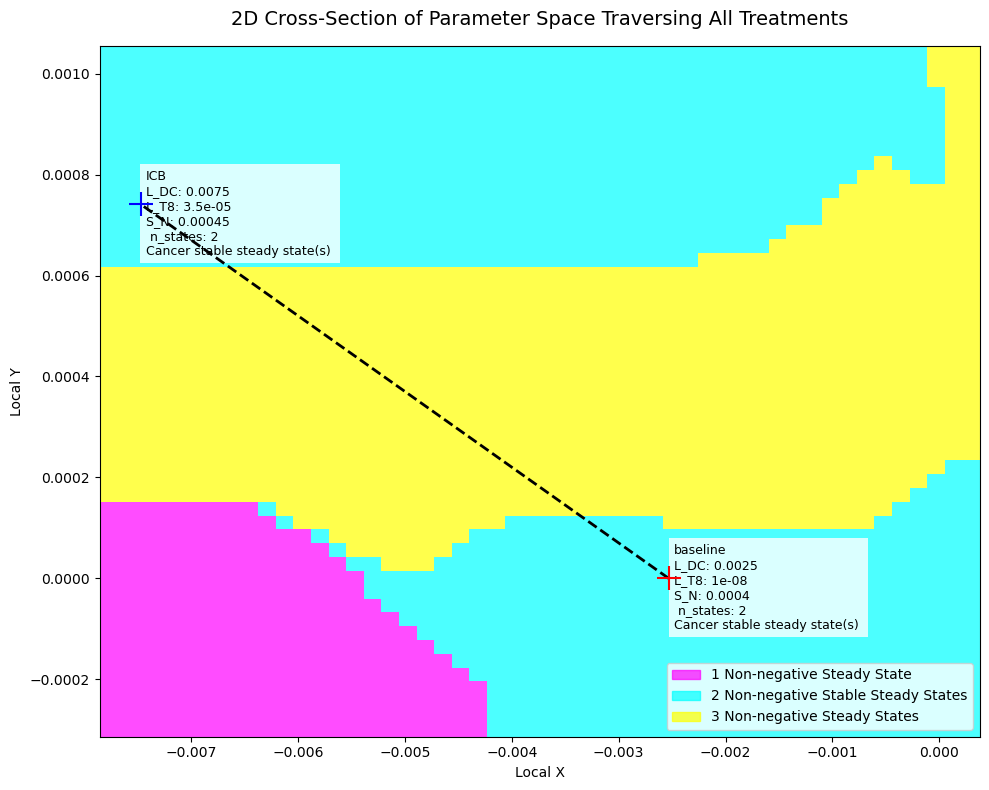

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ==========================================
# 1. Base Parameters Dictionary
# ==========================================
best_params = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300, "d_C": 0.17,
    "K_C": 0.4, "d_D": 0.1, "d_N": 0.1, "gamma_N": 150, "a_C": 0.5, 
    "beta_1": 0.4, "beta_2": 2e-4, "d_Tr": 0.2, "lambda_Tr_comb": 2e-4,
    "d_T8": 0.18, "K_Tr": 2.5e-4, "K_D": 4e-4
}
#T11
best_params = {'lambda_C': 2.0, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17,
               'lambda_DC_comb': 0.003, 'K_C': 0.4, 'd_D': 0.3, 'sigma_N': 0.0005, 'd_N': 0.13, 'gamma_N': 150, 'a_C': 0.5,
               'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.001, 'lambda_T8_comb': 0.0005, 
               'K_Tr': 0.0001, 'K_D': 0.0004}

p = best_params

# Treatment Data: [lambda_DC, lambda_T8,sigma_N]
# P1 = ICB, P2 = ICB+mut, P3 = untreated+mut, P4: untreated + no mut
# P1 = np.array([0.003, 0.01, 0.0005])#  arbitrary direction

#no mutagen
P2 = np.array([0.0025, 0.00000001,  0.0004]) #untreated
# P4= np.array([0.0095, 0.000003,  0.0005]) 
P3 = np.array([0.0075, 0.000035,  0.00045] ) #treated
P1 = np.cross(P2,P3)/2
                                                                            
# #mutagen
# P2 = np.array([0.002, 0.0002,  0.0004]) #untreated
# # P4= np.array([0.0095, 0.000003,  0.0005]) 
# P3 = np.array([0.003, 0.0005,  0.0005] ) #treated
# P1 = np.cross(P2,P3)/2

# #KPB25L
# best_params = {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17,
#                'K_C': 0.4, 'd_D': 1.0, 'd_N': 0.5, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01,
#                'K_Tr': 0.01, 'K_D': 0.0004}
# p = best_params

# #no mutagen
# P2 = np.array([0.0095, 0.000003,  0.0005]) #untreated
# # P4= np.array([0.0095, 0.000003,  0.0005]) 
# P3 = np.array([0.0075, 0.0004,  0.0001] ) #treated
# P1 = np.cross(P2,P3)/2

# # #mutagen
# P2 = np.array([0.0095, 0.00007,  0.0005]) #untreated
# # P4= np.array([0.0095, 0.000003,  0.0005]) 
# P3 = np.array([0.005, 0.0002,  0.0005] ) #treated
# P1 = np.cross(P2,P3)/2


labels = ['baseline','ICB']
colors = ['red', 'blue', 'green']

# ==========================================
# 2. Define the Custom 2D Plane (Gram-Schmidt)
# ==========================================
# Create two vectors on the plane starting from P1
V1 = P1 - P2
V2 = P3 - P2

# Make them orthogonal to act as our 2D X and Y axes
U1 = V1 / np.linalg.norm(V1)
V2_perp = V2 - np.dot(V2, U1) * U1
U2 = V2_perp / np.linalg.norm(V2_perp)

# Function to project 3D points onto our new 2D plane
def project_to_2d(pt):
    vec = pt - P1
    return np.array([np.dot(vec, U1), np.dot(vec, U2)])

proj_P1 = project_to_2d(P1)
proj_P2 = project_to_2d(P2)
proj_P3 = project_to_2d(P3)


# Define grid boundaries in the local 2D space (padding around the points)
x_min = min(proj_P1[0], proj_P2[0], proj_P3[0]) - 0.0003
x_max = max(proj_P1[0], proj_P2[0], proj_P3[0]) + 0.0003
y_min = min(proj_P1[1], proj_P2[1], proj_P3[1]) - 0.0003
y_max = max(proj_P1[1], proj_P2[1], proj_P3[1]) + 0.0003

# ==========================================
# 3. Vectorized Root Finding on the Plane
# ==========================================
res = 50 # High resolution for smooth boundaries
X, Y = np.meshgrid(np.linspace(x_min, x_max, res), np.linspace(y_min, y_max, res))

# Map the 2D grid back to 3D parameter space
LDC_grid = P1[0] + X * U1[0] + Y * U2[0]
LT8_grid = P1[1] + X * U1[1] + Y * U2[1]
SN_grid  = P1[2] + X * U1[2] + Y * U2[2]

# Ensure parameters don't dip below zero due to grid padding
LDC_grid = np.clip(LDC_grid, 1e-8, None)
LT8_grid = np.clip(LT8_grid, 1e-8, None)
SN_grid  = np.clip(SN_grid, 1e-8, None)

LDC_f = LDC_grid.flatten()[:, np.newaxis]
LT8_f = LT8_grid.flatten()[:, np.newaxis]
SN_f  = SN_grid.flatten()[:, np.newaxis]

# Sweep C (using ultra-high resolution to catch the thin fold boundaries)
C_M = p["C_M"]
C = np.linspace(1e-5, C_M * 0.999, 3000)[np.newaxis, :] 

# Master Equations
D = (LDC_f / p["d_D"]) * (C / (C + p["K_C"]))
Tr = (p["lambda_Tr_comb"] / p["d_Tr"]) * (C / (C + p["K_C"]))
T8 = (LT8_f / p["d_T8"]) * (D / (p["K_D"] + D)) / (1 + Tr / p["K_Tr"])
N_star = (p["lambda_C"] * (1 - C/C_M) - p["eta_8"]*T8 - p["d_C"]) / p["eta_N"]

term1 = SN_f
term2 = p["a_C"] * N_star *   (C / (1 + C/p["beta_1"] + N_star/p["beta_2"]))
term3 = - p["gamma_N"] * Tr * N_star
term4 = - p["d_N"] * N_star
f_C = term1 + term2 + term3 + term4



# Count zero crossings to find the number of positive steady states
#tolderance to 
tol = 1e-10
sign_f = np.sign(f_C)
# sign_f[np.abs(f_C)<tol] = 0

diffs = np.diff(sign_f,axis = 1)

roots_count = np.sum(diffs!=0,axis = 1)

roots = [[] for i in range(len(LDC_f))]
for i in range(len(LDC_f)): #cycle through grid points
    root_indicies = np.where((diffs[i] !=0))[0]
    for j in root_indicies:#cycle through roots
        root = (C[0,j],D[i,j],N_star[0,j],Tr[0,j],T8[i,j])
        if all(i >=0.0 for i in root):
            roots[i].append(root)
if p['d_N']!=0:
    roots_count +=1
    for i in range(len(roots)):
        roots[i].append((0.0,0.0,SN_f[i,0]/p['d_N'],0.0,0.0))
roots_count_stable = np.zeros(len(roots))
for i in range(len(roots)):
    n_stable = 0
    p = best_params.copy()
    p['lambda_DC_comb'] = LDC_f[i,0]
    p['lambda_T8_comb'] = LT8_f[i,0]
    p['sigma_N'] = SN_f[i,0]
    
    for root in roots[i]:
        stability,eigs,evecs = find_stability(p,root)
        if  stability == 1:
            n_stable +=1
    roots_count_stable[i] = n_stable
    roots_count[i] = len(roots[i])
roots_grid = roots_count.reshape((res, res))
from scipy.ndimage import median_filter,generic_filter

# roots_grid = median_filter(roots_grid,size = 4)
# roots_grid = median_filter(roots_grid,size = 6)
# roots_grid = median_filter(roots_grid,size = 10)
roots_grid = median_filter(roots_grid,size = 10)



# Map to requested colors: 1 root -> 0 (Magenta), 2 roots -> 1 (Cyan), 3 roots -> 2 (Yellow)
color_map_grid = np.zeros_like(roots_grid)
color_map_grid[roots_grid <= 1] = 0
color_map_grid[roots_grid == 2] = 1
color_map_grid[roots_grid >= 3] = 2

# find precise number of states
n_stable_states = []
n_states = []
cancer_states = []
for P in [P2,P3]:

    cancers = []
    stable_roots = []
    
    LDC = P[0]
    LT8 = P[1]
    SN = P[2]
    
    # Sweep C (using ultra-high resolution to catch the thin fold boundaries)
    C_M = p["C_M"]
    C = np.linspace(1e-5, C_M * 0.999, 3000)
    
    # Master Equations
    D = (LDC / p["d_D"]) * (C / (C + p["K_C"]))
    Tr = (p["lambda_Tr_comb"] / p["d_Tr"]) * (C / (C + p["K_C"]))
    T8 = (LT8 / p["d_T8"]) * (D / (p["K_D"] + D)) / (1 + Tr / p["K_Tr"])
    N_star = (p["lambda_C"] * (1 - C/C_M) - p["eta_8"]*T8 - p["d_C"]) / p["eta_N"]
    
    term1 = SN
    term2 = p["a_C"] * N_star * (C / (1 + C/p["beta_1"] + N_star/p["beta_2"]))
    term3 = - p["gamma_N"] * Tr * N_star
    term4 = - p["d_N"] * N_star
    f_C = term1 + term2 + term3 + term4
    
    
    # Count zero crossings to find the number of positive steady states
    #tolderance to 
    # tol = 1e-10
    sign_f = np.sign(f_C)
    # sign_f[np.abs(f_C)<tol] = 0
    
    diffs = np.diff(sign_f)
    root_indices = np.where(diffs != 0)[0]
    
    roots = []

    root_indicies = np.where((diffs !=0))[0]
    for j in root_indicies: #cycle through roots
        root = (C[j],D[j],N_star[j],Tr[j],T8[j])
        if all(i >= 0.0 for i in root):
            roots.append(root)
    if p['d_N']!=0:
        roots_count +=1
        
        roots.append((0.0,0.0,SN/p['d_N'],0.0,0.0))

    n_stable = 0
    p = best_params.copy()
    p['lambda_DC_comb'] = LDC
    p['lambda_T8_comb'] = LT8
    p['sigma_N'] = SN


    for root in roots:
        stability,eigs,evecs = find_stability(p,root)
        print(root)
        print(stability)
        print(eigs)
        for i,eig in enumerate(eigs):
            if eig>0:
                print(evecs[i])
        if stability == 1:
            n_stable +=1
            stable_roots.append(root)
    
    n = n_stable
    n_stable_states.append(n_stable)
    n_states.append(len(roots))
    
    
    for root in stable_roots:
        print(root)
        y = root
        cancer = y[0]
        cancers.append(f"{cancer:.2g}")
                
    cancers_str= ','.join(cancers)
    cancer_states.append(cancers_str)


# ==========================================
# 4. Plotting the 2D Slice
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))

# Apply your exact color code
cmap = ListedColormap(['magenta', 'cyan', 'yellow'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

# Plot the landscape
c = ax.pcolormesh(X, Y, color_map_grid, cmap=cmap, norm=norm, shading='auto', alpha=0.7)

# Plot the treatment trajectory
trajs_X = [ proj_P2[0], proj_P3[0]]
trajs_Y = [ proj_P2[1], proj_P3[1]]
ax.plot(trajs_X,trajs_Y, color='black', linestyle='--', linewidth=2, zorder=5)



# Plot the treatment stars
for i, pt in enumerate([proj_P2, proj_P3]):
    ax.scatter(pt[0], pt[1], color=colors[i], marker='+', s=300, edgecolor='black', zorder=10)
    # Adding a text box with the true 3D parameters for clarity
    true_pt = [P2, P3][i]
    label_text = f'{labels[i]}\nL_DC: {true_pt[0]}\nL_T8: {true_pt[1]}\nS_N: {true_pt[2]}\n n_states: {n_states[i]}\nCancer stable steady state(s) {cancer_states[i]}'
    ax.text(pt[0] + 0.00005, pt[1] - 0.0001, label_text, fontsize=9, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Formatting
ax.set_title("2D Cross-Section of Parameter Space Traversing All Treatments", fontsize=14, pad=15)
ax.set_xlabel("Local X")
ax.set_ylabel("Local Y")

# Create custom legend for the regions
import matplotlib.patches as mpatches
mag_patch = mpatches.Patch(color='magenta', alpha=0.7, label='1 Non-negative Steady State')
cya_patch = mpatches.Patch(color='cyan', alpha=0.7, label='2 Non-negative Stable Steady States')
yel_patch = mpatches.Patch(color='yellow', alpha=0.7, label='3 Non-negative Steady States')
ax.legend(handles=[mag_patch, cya_patch, yel_patch], loc='lower right')

plt.tight_layout()
plt.show()

(np.float64(0.528184251417139), np.float64(0.005405985267258938), np.float64(0.0008505829705384271), np.float64(0.0008535766211461482), np.float64(0.00025736370885403296))
0
[ 1.32620213 -1.00000001 -0.32675832 -0.21455589 -0.01      ]
[ 9.99998198e-01  1.19205581e-06  9.99923283e-01 -9.99890958e-01
  6.20078937e-02]
(0.0, 0.0, np.float64(0.001), 0.0, 0.0)
0
[-0.01       -1.         -0.48611111 -0.2         1.33      ]
[ 1.00000000e+00 -7.57554019e-03  0.00000000e+00  0.00000000e+00
  5.70481473e-05]
(np.float64(0.00214188396132044), np.float64(3.994642276915481e-05), np.float64(0.0004491764591247639), np.float64(7.98928455383096e-06), np.float64(0.0036290358867786597))
0
[ 1.32410157 -1.00782416  0.00369712 -0.2000673  -0.45115429]
[-0.99995582 -0.30899705  0.66808528  0.08722752  0.32697788]
[-2.03673544e-05  7.26462130e-05 -2.59155431e-04  2.58019629e-01
  9.44740113e-01]
(0.0, 0.0, np.float64(0.0002), 0.0, 0.0)
0
[-0.01  -1.    -0.375 -0.2    1.33 ]
[ 1.         -0.71065111  0.    

/tmp/ipykernel_869/3106532672.py:283: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pt[0], pt[1], color=colors[i], marker='+', s=300, edgecolor='black', zorder=10)


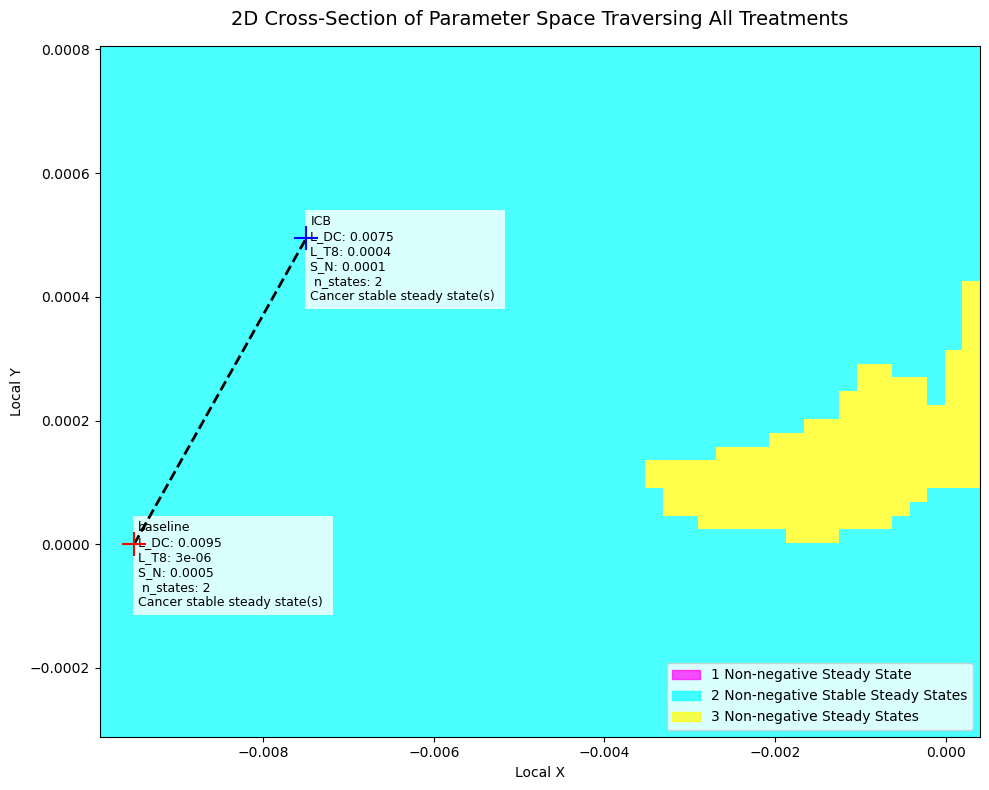

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ==========================================
# 1. Base Parameters Dictionary
# ==========================================
best_params = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300, "d_C": 0.17,
    "K_C": 0.4, "d_D": 0.1, "d_N": 0.1, "gamma_N": 150, "a_C": 0.5, 
    "beta_1": 0.4, "beta_2": 2e-4, "d_Tr": 0.2, "lambda_Tr_comb": 2e-4,
    "d_T8": 0.18, "K_Tr": 2.5e-4, "K_D": 4e-4
}
#T11
best_params = {'lambda_C': 2.0, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17,
               'lambda_DC_comb': 0.003, 'K_C': 0.4, 'd_D': 0.3, 'sigma_N': 0.0005, 'd_N': 0.13, 'gamma_N': 150, 'a_C': 0.5,
               'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.001, 'lambda_T8_comb': 0.0005, 
               'K_Tr': 0.0001, 'K_D': 0.0004}

p = best_params

# Treatment Data: [lambda_DC, lambda_T8,sigma_N]
# P1 = ICB, P2 = ICB+mut, P3 = untreated+mut, P4: untreated + no mut
# P1 = np.array([0.003, 0.01, 0.0005])#  arbitrary direction

#no mutagen
P2 = np.array([0.0025, 0.00000001,  0.0004]) #untreated
# P4= np.array([0.0095, 0.000003,  0.0005]) 
P3 = np.array([0.0075, 0.000035,  0.00045] ) #treated
P1 = np.cross(P2,P3)/2
                                                                            
#mutagen
P2 = np.array([0.002, 0.0002,  0.0004]) #untreated
# P4= np.array([0.0095, 0.000003,  0.0005]) 
P3 = np.array([0.003, 0.0005,  0.0005] ) #treated
P1 = np.cross(P2,P3)/2

#KPB25L
best_params = {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17,
               'K_C': 0.4, 'd_D': 1.0, 'd_N': 0.5, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01,
               'K_Tr': 0.01, 'K_D': 0.0004}
p = best_params

#no mutagen
P2 = np.array([0.0095, 0.000003,  0.0005]) #untreated
# P4= np.array([0.0095, 0.000003,  0.0005]) 
P3 = np.array([0.0075, 0.0004,  0.0001] ) #treated
P1 = np.cross(P2,P3)/2

# # #mutagen
# P2 = np.array([0.0095, 0.00007,  0.0005]) #untreated
# # P4= np.array([0.0095, 0.000003,  0.0005]) 
# P3 = np.array([0.005, 0.0002,  0.0005] ) #treated
# P1 = np.cross(P2,P3)/2


labels = ['baseline','ICB']
colors = ['red', 'blue', 'green']

# ==========================================
# 2. Define the Custom 2D Plane (Gram-Schmidt)
# ==========================================
# Create two vectors on the plane starting from P1
V1 = P1 - P2
V2 = P3 - P2

# Make them orthogonal to act as our 2D X and Y axes
U1 = V1 / np.linalg.norm(V1)
V2_perp = V2 - np.dot(V2, U1) * U1
U2 = V2_perp / np.linalg.norm(V2_perp)

# Function to project 3D points onto our new 2D plane
def project_to_2d(pt):
    vec = pt - P1
    return np.array([np.dot(vec, U1), np.dot(vec, U2)])

proj_P1 = project_to_2d(P1)
proj_P2 = project_to_2d(P2)
proj_P3 = project_to_2d(P3)


# Define grid boundaries in the local 2D space (padding around the points)
x_min = min(proj_P1[0], proj_P2[0], proj_P3[0]) - 0.0003
x_max = max(proj_P1[0], proj_P2[0], proj_P3[0]) + 0.0003
y_min = min(proj_P1[1], proj_P2[1], proj_P3[1]) - 0.0003
y_max = max(proj_P1[1], proj_P2[1], proj_P3[1]) + 0.0003

# ==========================================
# 3. Vectorized Root Finding on the Plane
# ==========================================
res = 50 # High resolution for smooth boundaries
X, Y = np.meshgrid(np.linspace(x_min, x_max, res), np.linspace(y_min, y_max, res))

# Map the 2D grid back to 3D parameter space
LDC_grid = P1[0] + X * U1[0] + Y * U2[0]
LT8_grid = P1[1] + X * U1[1] + Y * U2[1]
SN_grid  = P1[2] + X * U1[2] + Y * U2[2]

# Ensure parameters don't dip below zero due to grid padding
LDC_grid = np.clip(LDC_grid, 1e-8, None)
LT8_grid = np.clip(LT8_grid, 1e-8, None)
SN_grid  = np.clip(SN_grid, 1e-8, None)

LDC_f = LDC_grid.flatten()[:, np.newaxis]
LT8_f = LT8_grid.flatten()[:, np.newaxis]
SN_f  = SN_grid.flatten()[:, np.newaxis]

# Sweep C (using ultra-high resolution to catch the thin fold boundaries)
C_M = p["C_M"]
C = np.linspace(1e-5, C_M * 0.999, 3000)[np.newaxis, :] 

# Master Equations
D = (LDC_f / p["d_D"]) * (C / (C + p["K_C"]))
Tr = (p["lambda_Tr_comb"] / p["d_Tr"]) * (C / (C + p["K_C"]))
T8 = (LT8_f / p["d_T8"]) * (D / (p["K_D"] + D)) / (1 + Tr / p["K_Tr"])
N_star = (p["lambda_C"] * (1 - C/C_M) - p["eta_8"]*T8 - p["d_C"]) / p["eta_N"]

term1 = SN_f
term2 = p["a_C"] * N_star *   (C / (1 + C/p["beta_1"] + N_star/p["beta_2"]))
term3 = - p["gamma_N"] * Tr * N_star
term4 = - p["d_N"] * N_star
f_C = term1 + term2 + term3 + term4



# Count zero crossings to find the number of positive steady states
#tolderance to 
tol = 1e-10
sign_f = np.sign(f_C)
# sign_f[np.abs(f_C)<tol] = 0

diffs = np.diff(sign_f,axis = 1)

roots_count = np.sum(diffs!=0,axis = 1)

roots = [[] for i in range(len(LDC_f))]
for i in range(len(LDC_f)): #cycle through grid points
    root_indicies = np.where((diffs[i] !=0))[0]
    for j in root_indicies:#cycle through roots
        root = (C[0,j],D[i,j],N_star[0,j],Tr[0,j],T8[i,j])
        if all(i >=0.0 for i in root):
            roots[i].append(root)
if p['d_N']!=0:
    roots_count +=1
    for i in range(len(roots)):
        roots[i].append((0.0,0.0,SN_f[i,0]/p['d_N'],0.0,0.0))
roots_count_stable = np.zeros(len(roots))
for i in range(len(roots)):
    n_stable = 0
    p = best_params.copy()
    p['lambda_DC_comb'] = LDC_f[i,0]
    p['lambda_T8_comb'] = LT8_f[i,0]
    p['sigma_N'] = SN_f[i,0]
    
    for root in roots[i]:
        stability,eigs,evecs = find_stability(p,root)
        if  stability == 1:
            n_stable +=1
    roots_count_stable[i] = n_stable
    roots_count[i] = len(roots[i])
roots_grid = roots_count.reshape((res, res))
from scipy.ndimage import median_filter,generic_filter

# roots_grid = median_filter(roots_grid,size = 4)
# roots_grid = median_filter(roots_grid,size = 6)
# roots_grid = median_filter(roots_grid,size = 10)
roots_grid = median_filter(roots_grid,size = 10)



# Map to requested colors: 1 root -> 0 (Magenta), 2 roots -> 1 (Cyan), 3 roots -> 2 (Yellow)
color_map_grid = np.zeros_like(roots_grid)
color_map_grid[roots_grid <= 1] = 0
color_map_grid[roots_grid == 2] = 1
color_map_grid[roots_grid >= 3] = 2

# find precise number of states
n_stable_states = []
n_states = []
cancer_states = []
for P in [P2,P3]:

    cancers = []
    stable_roots = []
    
    LDC = P[0]
    LT8 = P[1]
    SN = P[2]
    
    # Sweep C (using ultra-high resolution to catch the thin fold boundaries)
    C_M = p["C_M"]
    C = np.linspace(1e-5, C_M * 0.999, 3000)
    
    # Master Equations
    D = (LDC / p["d_D"]) * (C / (C + p["K_C"]))
    Tr = (p["lambda_Tr_comb"] / p["d_Tr"]) * (C / (C + p["K_C"]))
    T8 = (LT8 / p["d_T8"]) * (D / (p["K_D"] + D)) / (1 + Tr / p["K_Tr"])
    N_star = (p["lambda_C"] * (1 - C/C_M) - p["eta_8"]*T8 - p["d_C"]) / p["eta_N"]
    
    term1 = SN
    term2 = p["a_C"] * N_star * (C / (1 + C/p["beta_1"] + N_star/p["beta_2"]))
    term3 = - p["gamma_N"] * Tr * N_star
    term4 = - p["d_N"] * N_star
    f_C = term1 + term2 + term3 + term4
    
    
    # Count zero crossings to find the number of positive steady states
    #tolderance to 
    # tol = 1e-10
    sign_f = np.sign(f_C)
    # sign_f[np.abs(f_C)<tol] = 0
    
    diffs = np.diff(sign_f)
    root_indices = np.where(diffs != 0)[0]
    
    roots = []

    root_indicies = np.where((diffs !=0))[0]
    for j in root_indicies: #cycle through roots
        root = (C[j],D[j],N_star[j],Tr[j],T8[j])
        if all(i >= 0.0 for i in root):
            roots.append(root)
    if p['d_N']!=0:
        roots_count +=1
        
        roots.append((0.0,0.0,SN/p['d_N'],0.0,0.0))

    n_stable = 0
    p = best_params.copy()
    p['lambda_DC_comb'] = LDC
    p['lambda_T8_comb'] = LT8
    p['sigma_N'] = SN


    for root in roots:
        stability,eigs,evecs = find_stability(p,root)
        print(root)
        print(stability)
        print(eigs)
        for i,eig in enumerate(eigs):
            if eig>0:
                print(evecs[i])
        if stability == 1:
            n_stable +=1
            stable_roots.append(root)
    
    n = n_stable
    n_stable_states.append(n_stable)
    n_states.append(len(roots))
    
    
    for root in stable_roots:
        print(root)
        y = root
        cancer = y[0]
        cancers.append(f"{cancer:.2g}")
                
    cancers_str= ','.join(cancers)
    cancer_states.append(cancers_str)


# ==========================================
# 4. Plotting the 2D Slice
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))

# Apply your exact color code
cmap = ListedColormap(['magenta', 'cyan', 'yellow'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

# Plot the landscape
c = ax.pcolormesh(X, Y, color_map_grid, cmap=cmap, norm=norm, shading='auto', alpha=0.7)

# Plot the treatment trajectory
trajs_X = [ proj_P2[0], proj_P3[0]]
trajs_Y = [ proj_P2[1], proj_P3[1]]
ax.plot(trajs_X,trajs_Y, color='black', linestyle='--', linewidth=2, zorder=5)



# Plot the treatment stars
for i, pt in enumerate([proj_P2, proj_P3]):
    ax.scatter(pt[0], pt[1], color=colors[i], marker='+', s=300, edgecolor='black', zorder=10)
    # Adding a text box with the true 3D parameters for clarity
    true_pt = [P2, P3][i]
    label_text = f'{labels[i]}\nL_DC: {true_pt[0]}\nL_T8: {true_pt[1]}\nS_N: {true_pt[2]}\n n_states: {n_states[i]}\nCancer stable steady state(s) {cancer_states[i]}'
    ax.text(pt[0] + 0.00005, pt[1] - 0.0001, label_text, fontsize=9, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Formatting
ax.set_title("2D Cross-Section of Parameter Space Traversing All Treatments", fontsize=14, pad=15)
ax.set_xlabel("Local X")
ax.set_ylabel("Local Y")

# Create custom legend for the regions
import matplotlib.patches as mpatches
mag_patch = mpatches.Patch(color='magenta', alpha=0.7, label='1 Non-negative Steady State')
cya_patch = mpatches.Patch(color='cyan', alpha=0.7, label='2 Non-negative Stable Steady States')
yel_patch = mpatches.Patch(color='yellow', alpha=0.7, label='3 Non-negative Steady States')
ax.legend(handles=[mag_patch, cya_patch, yel_patch], loc='lower right')

plt.tight_layout()
plt.show()

# Investigate the optimal time-course of APOBEC treatment

Define the maximum parameter shifts as 2x(APOBEC - ICB)
(Assume that, the maximum dose of APOBEC is 2X the current level; 
Applying it can result in 2X the parameter shift from what we found)

As the paper, use the forward-backward seep method
Reason: 
State equations run forward in time; adjoint equations run backward in time

Refine the model, first consider the ICB infusion problem

Replicate the paper's model with initial values in the paper. 
However, use simplified ODE we developed. 

Starting Forward-Backward Sweep Method...
Iteration 25, Error: 0.01872
Iteration 50, Error: 0.01005
Iteration 75, Error: 0.00564
Iteration 100, Error: 0.00324
Iteration 125, Error: 0.00187
Iteration 150, Error: 0.00109
Iteration 175, Error: 0.00063
Iteration 200, Error: 0.00037
Iteration 225, Error: 0.00021
Iteration 250, Error: 0.00012
Converged in 260 iterations.


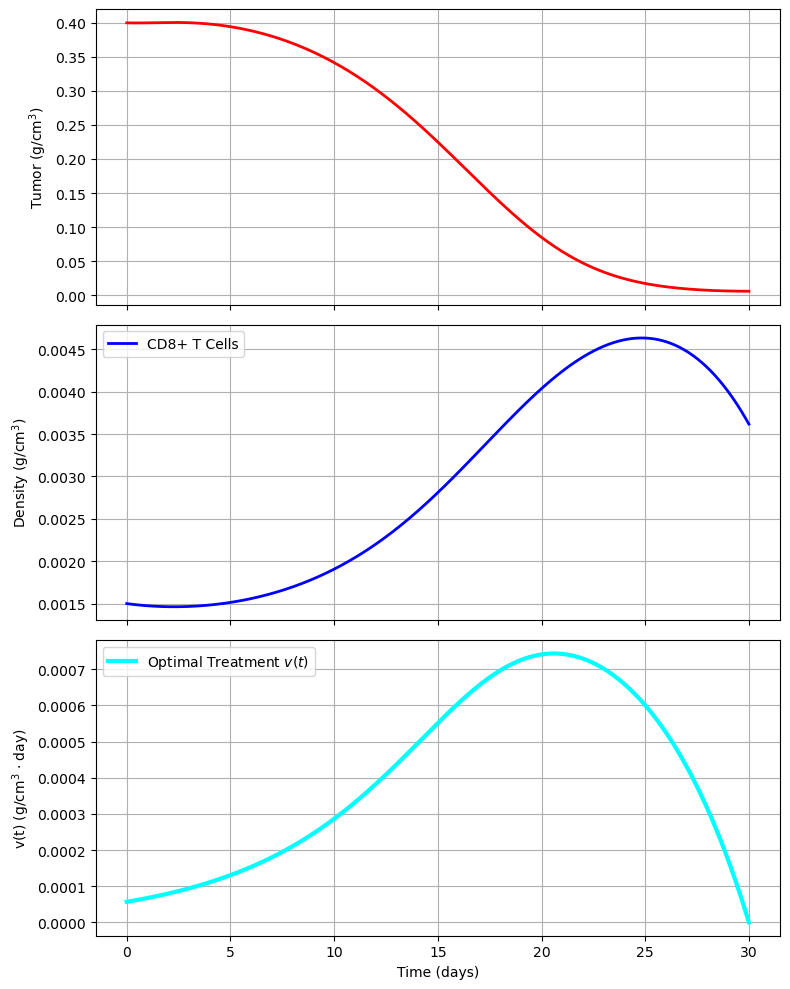

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (Strictly from Table 1)
# ==========================================
p = {
    # Tumor
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    # DCs (L_DC = lambda_DC * D_0 = 4 * 2e-5)
    "L_DC": 8e-5, "K_C": 0.4, "d_D": 0.1,
    # NK cells
    "sigma_N": 5e-5, "d_N": 0.1, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    # Tregs (L_Tr = lambda_Tr * T_10 = 0.5 * 4e-4)
    "d_Treg": 0.2, "L_Tr": 2e-4, 
    # CD8 T cells (L_T8 = lambda_T8 * T_80 = 5.4 * 2e-4)
    "d_T8": 0.18, "L_T8": 1.08e-3, "K_Treg": 2.5e-4, "K_D": 4e-4
}

# Optimization Weights (From Paper)
a = 5000.0     # Penalty for drug injection
b = 0.0001     # Continuous penalty for tumor burden

# Time Grid (30 Days)
T_final = 30.0       
N_steps = 1000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)

# ==========================================
# 2. Derivative Functions for RK4
# ==========================================
def state_derivatives(x, v_val):
    C, D, N, Tr, T8 = x
    
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["L_DC"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["L_Tr"] * C / (p["K_C"] + C)
    
    # Notice v_val is now an additive infusion term here
    dT8 = -p["d_T8"]*T8 + p["L_T8"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, v_val):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    # Notice the 'b' term added to the dl1 equation
    dl1 = -( b + l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["L_DC"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["L_Tr"] * p["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*p["d_D"] + l5*(p["L_T8"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*p["d_Treg"] + l5*(p["L_T8"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] ) 
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Initialization & FBSM Loop
# ==========================================
x = np.zeros((5, N_steps))
lam = np.zeros((5, N_steps))

# Initial Conditions (From Table 2)
x[:, 0] = [0.4, 0.0004, 0.0003, 0.0005, 0.0015] 
v = np.zeros(N_steps)

tolerance = 1e-4
max_iter = 500
test = tolerance + 1
iteration = 0

print("Starting Forward-Backward Sweep Method...")

while test > tolerance and iteration < max_iter:
    old_v, old_x, old_lam = v.copy(), x.copy(), lam.copy()
    
    # --- STEP A: FORWARD SWEEP ---
    for i in range(N_steps - 1):
        v_mid = 0.5 * (v[i] + v[i+1])
        current_x = np.maximum(x[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1])
        
        x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
        
    # --- STEP B: BACKWARD SWEEP ---
    # Transversality: Penalizing terminal tumor burden
    lam[:, -1] = 0.0
    lam[0, -1] = 1.0 
    
    for i in range(N_steps - 1, 0, -1):
        v_mid = 0.5 * (v[i] + v[i-1])
        x_mid = 0.5 * (x[:, i] + x[:, i-1])
        
        k1 = dt * adjoint_derivatives(x[:, i], lam[:, i], v[i])
        k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, v_mid)
        k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, v_mid)
        k4 = dt * adjoint_derivatives(x[:, i-1], lam[:, i] - k3, v[i-1])
        
        lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
        
    # --- STEP C: CONTROL UPDATE ---
    v_new = np.zeros(N_steps)
    for i in range(N_steps):
        # Optimal Control Law from paper: unconstrained to allow the bell curve
        v_calc = -lam[4, i] / (2 * a)
        v_new[i] = max(0.0, v_calc) 
        
    # --- STEP D: CONVEX COMBINATION & CHECK ---
    v = 0.05 * v_new + 0.95 * old_v # Slower learning rate for stability
    
    diff_v = np.sum(np.abs(v - old_v)) / (np.sum(np.abs(v)) + 1e-10)
    diff_x = np.sum(np.abs(x - old_x)) / (np.sum(np.abs(x)) + 1e-10)
    diff_lam = np.sum(np.abs(lam - old_lam)) / (np.sum(np.abs(lam)) + 1e-10)
    
    test = diff_v + diff_x + diff_lam
    iteration += 1
    
    if iteration % 25 == 0:
        print(f"Iteration {iteration}, Error: {test:.5f}")

print(f"Converged in {iteration} iterations.")

# ==========================================
# 4. Plotting (Matched to Paper Style)
# ==========================================
fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Tumor Plot
axs[0].plot(t, x[0, :], 'r-', linewidth=2)
axs[0].set_ylabel('Tumor (g/cm$^3$)')
axs[0].grid(True)

# Immune Plot (Just T8 as shown in paper sometimes, or add NK if needed)
axs[1].plot(t, x[4, :], 'b-', linewidth=2, label='CD8+ T Cells')
axs[1].set_ylabel('Density (g/cm$^3$)')
axs[1].legend()
axs[1].grid(True)

# Optimal Control Plot (The Bell Curve)
axs[2].plot(t, v, 'cyan', linewidth=3, label='Optimal Treatment $v(t)$')
axs[2].set_xlabel('Time (days)')
axs[2].set_ylabel('v(t) (g/cm$^3$ $\cdot$ day)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

Generating data for Graphs C and D (Sweeping 'a')...
Generating data for Graphs E and F (Sweeping 'b')...
Plotting...


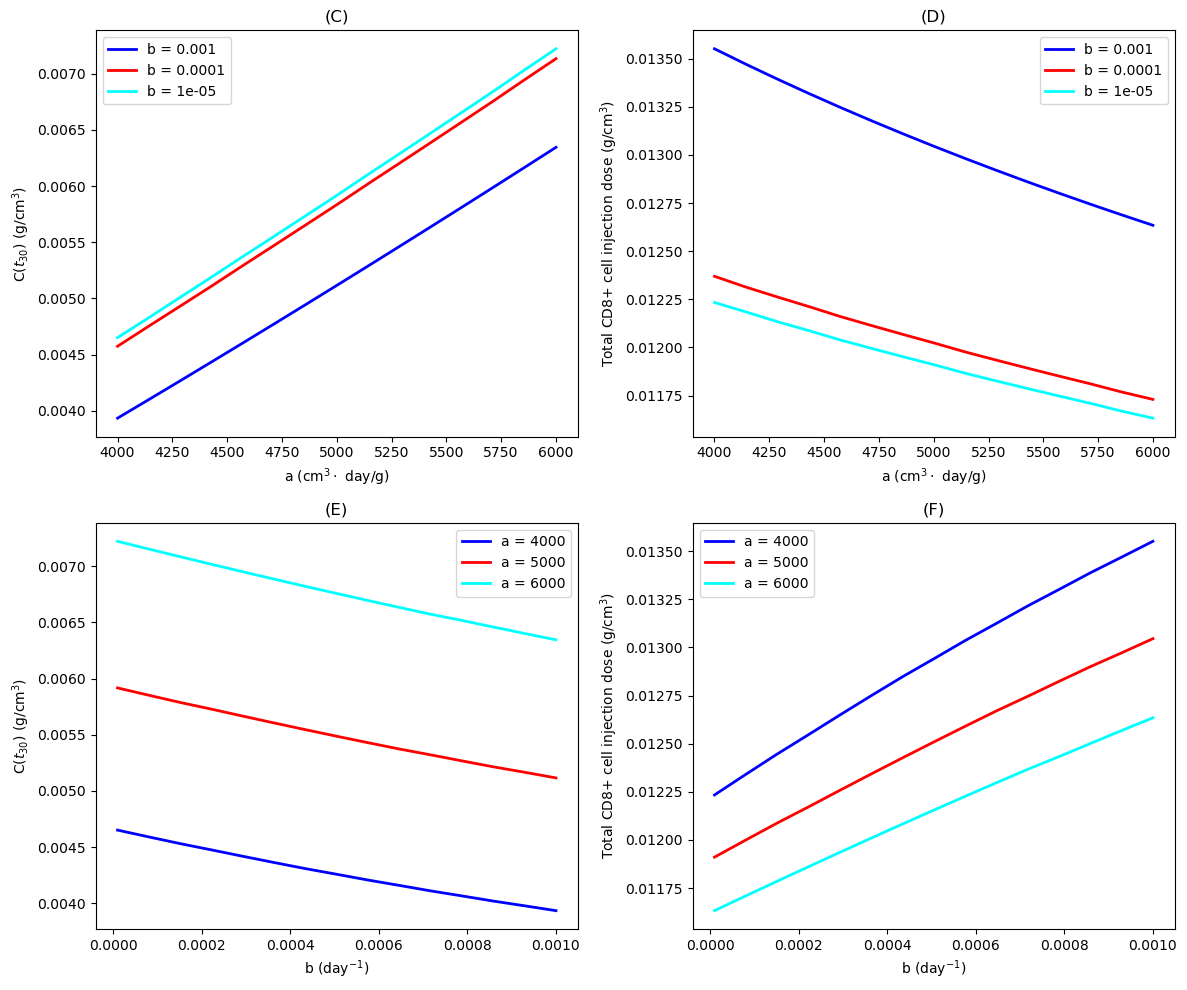

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (Strictly from Table 1)
# ==========================================
p = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    "L_DC": 8e-5, "K_C": 0.4, "d_D": 0.1,
    "sigma_N": 5e-5, "d_N": 0.1, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    "d_Treg": 0.2, "L_Tr": 2e-4, 
    "d_T8": 0.18, "L_T8": 1.08e-3, "K_Treg": 2.5e-4, "K_D": 4e-4
}

# Time Grid (30 Days)
T_final = 30.0       
N_steps = 1000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)
x0 = [0.4, 0.0004, 0.0003, 0.0005, 0.0015]

# ==========================================
# 2. Derivative Functions
# ==========================================
def state_derivatives(x, v_val):
    C, D, N, Tr, T8 = x
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["L_DC"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["L_Tr"] * C / (p["K_C"] + C)
    dT8 = -p["d_T8"]*T8 + p["L_T8"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"])) + v_val
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, v_val, b_weight):
    # Notice: b_weight is now an explicitly passed argument!
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    dl1 = -( b_weight + l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["L_DC"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["L_Tr"] * p["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*p["d_D"] + l5*(p["L_T8"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*p["d_Treg"] + l5*(p["L_T8"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] ) 
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Optimization Wrapper
# ==========================================
def solve_optimal_control(a_weight, b_weight, max_iter=200, tolerance=1e-3):
    """Runs the FBSM for specific a and b, returns C(30) and Total Dose."""
    x = np.zeros((5, N_steps))
    lam = np.zeros((5, N_steps))
    x[:, 0] = x0
    v = np.zeros(N_steps)
    
    test = tolerance + 1
    iteration = 0
    
    while test > tolerance and iteration < max_iter:
        old_v = v.copy()
        
        # STEP A: FORWARD SWEEP
        for i in range(N_steps - 1):
            v_mid = 0.5 * (v[i] + v[i+1])
            current_x = np.maximum(x[:, i], 0.0)
            
            k1 = dt * state_derivatives(current_x, v[i])
            k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
            k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
            k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1])
            
            x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
            
        # STEP B: BACKWARD SWEEP
        lam[:, -1] = 0.0
        lam[0, -1] = 1.0 
        
        for i in range(N_steps - 1, 0, -1):
            v_mid = 0.5 * (v[i] + v[i-1])
            x_mid = 0.5 * (x[:, i] + x[:, i-1])
            
            k1 = dt * adjoint_derivatives(x[:, i], lam[:, i], v[i], b_weight)
            k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, v_mid, b_weight)
            k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, v_mid, b_weight)
            k4 = dt * adjoint_derivatives(x[:, i-1], lam[:, i] - k3, v[i-1], b_weight)
            
            lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
            
        # STEP C: CONTROL UPDATE
        v_new = np.zeros(N_steps)
        for i in range(N_steps):
            v_new[i] = max(0.0, -lam[4, i] / (2 * a_weight))
            
        # STEP D: CONVEX COMBINATION
        v = 0.1 * v_new + 0.9 * old_v 
        diff_v = np.sum(np.abs(v - old_v)) / (np.sum(np.abs(v)) + 1e-10)
        test = diff_v
        iteration += 1

    C_30 = x[0, -1]
    total_dose = np.sum(v) * dt # Integral of v(t) over time
    return C_30, total_dose

# ==========================================
# 4. Generating the Data (Parameter Sweeps)
# ==========================================
num_points = 15 # Set to 30+ later for smoother lines; kept lower for reasonable runtime

print("Generating data for Graphs C and D (Sweeping 'a')...")
a_range = np.linspace(4000, 6000, num_points)
b_fixed_list = [0.001, 0.0001, 0.00001]
results_C = {b: [] for b in b_fixed_list}
results_D = {b: [] for b in b_fixed_list}

for b in b_fixed_list:
    for a in a_range:
        c30, dose = solve_optimal_control(a, b)
        results_C[b].append(c30)
        results_D[b].append(dose)

print("Generating data for Graphs E and F (Sweeping 'b')...")
b_range = np.linspace(1e-5, 1e-3, num_points)
a_fixed_list = [4000, 5000, 6000]
results_E = {a: [] for a in a_fixed_list}
results_F = {a: [] for a in a_fixed_list}

for a in a_fixed_list:
    for b in b_range:
        c30, dose = solve_optimal_control(a, b)
        results_E[a].append(c30)
        results_F[a].append(dose)

print("Plotting...")

# ==========================================
# 5. Plotting the 4 Graphs
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Colors matching the paper
colors_b = {0.001: 'blue', 0.0001: 'red', 0.00001: 'cyan'}
colors_a = {4000: 'blue', 5000: 'red', 6000: 'cyan'}

# Graph C: C(t30) vs a
for b in b_fixed_list:
    axs[0, 0].plot(a_range, results_C[b], color=colors_b[b], linewidth=2, label=f'b = {b}')
axs[0, 0].set_xlabel('a (cm$^3 \cdot$ day/g)')
axs[0, 0].set_ylabel('C($t_{30}$) (g/cm$^3$)')
axs[0, 0].set_title('(C)')
axs[0, 0].legend()

# Graph D: Total Dose vs a
for b in b_fixed_list:
    axs[0, 1].plot(a_range, results_D[b], color=colors_b[b], linewidth=2, label=f'b = {b}')
axs[0, 1].set_xlabel('a (cm$^3 \cdot$ day/g)')
axs[0, 1].set_ylabel('Total CD8+ cell injection dose (g/cm$^3$)')
axs[0, 1].set_title('(D)')
axs[0, 1].legend()

# Graph E: C(t30) vs b
for a in a_fixed_list:
    axs[1, 0].plot(b_range, results_E[a], color=colors_a[a], linewidth=2, label=f'a = {a}')
axs[1, 0].set_xlabel('b (day$^{-1}$)')
axs[1, 0].set_ylabel('C($t_{30}$) (g/cm$^3$)')
axs[1, 0].set_title('(E)')
axs[1, 0].legend()

# Graph F: Total Dose vs b
for a in a_fixed_list:
    axs[1, 1].plot(b_range, results_F[a], color=colors_a[a], linewidth=2, label=f'a = {a}')
axs[1, 1].set_xlabel('b (day$^{-1}$)')
axs[1, 1].set_ylabel('Total CD8+ cell injection dose (g/cm$^3$)')
axs[1, 1].set_title('(F)')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

Starting Combination Therapy Co-Optimization...
Iteration 10, Error: 5882.46602
Iteration 20, Error: 2.93979
Iteration 30, Error: 2.86148
Iteration 40, Error: 5457.11799
Iteration 50, Error: 2.93941
Iteration 60, Error: 2.86148
Iteration 70, Error: 5457.11793
Iteration 80, Error: 2.93941
Iteration 90, Error: 2.86148
Iteration 100, Error: 5457.11793
Iteration 110, Error: 2.93941
Iteration 120, Error: 2.86148
Iteration 130, Error: 5457.11793
Iteration 140, Error: 2.93941
Iteration 150, Error: 2.86148
Iteration 160, Error: 5457.11793
Iteration 170, Error: 2.93941
Iteration 180, Error: 2.86148
Iteration 190, Error: 5457.11793
Iteration 200, Error: 2.93941
Iteration 210, Error: 2.86148
Iteration 220, Error: 5457.11793
Iteration 230, Error: 2.93941
Iteration 240, Error: 2.86148
Iteration 250, Error: 5457.11793
Iteration 260, Error: 2.93941
Iteration 270, Error: 2.86148
Iteration 280, Error: 5457.11793
Iteration 290, Error: 2.93941
Iteration 300, Error: 2.86148
Iteration 310, Error: 5457.1179

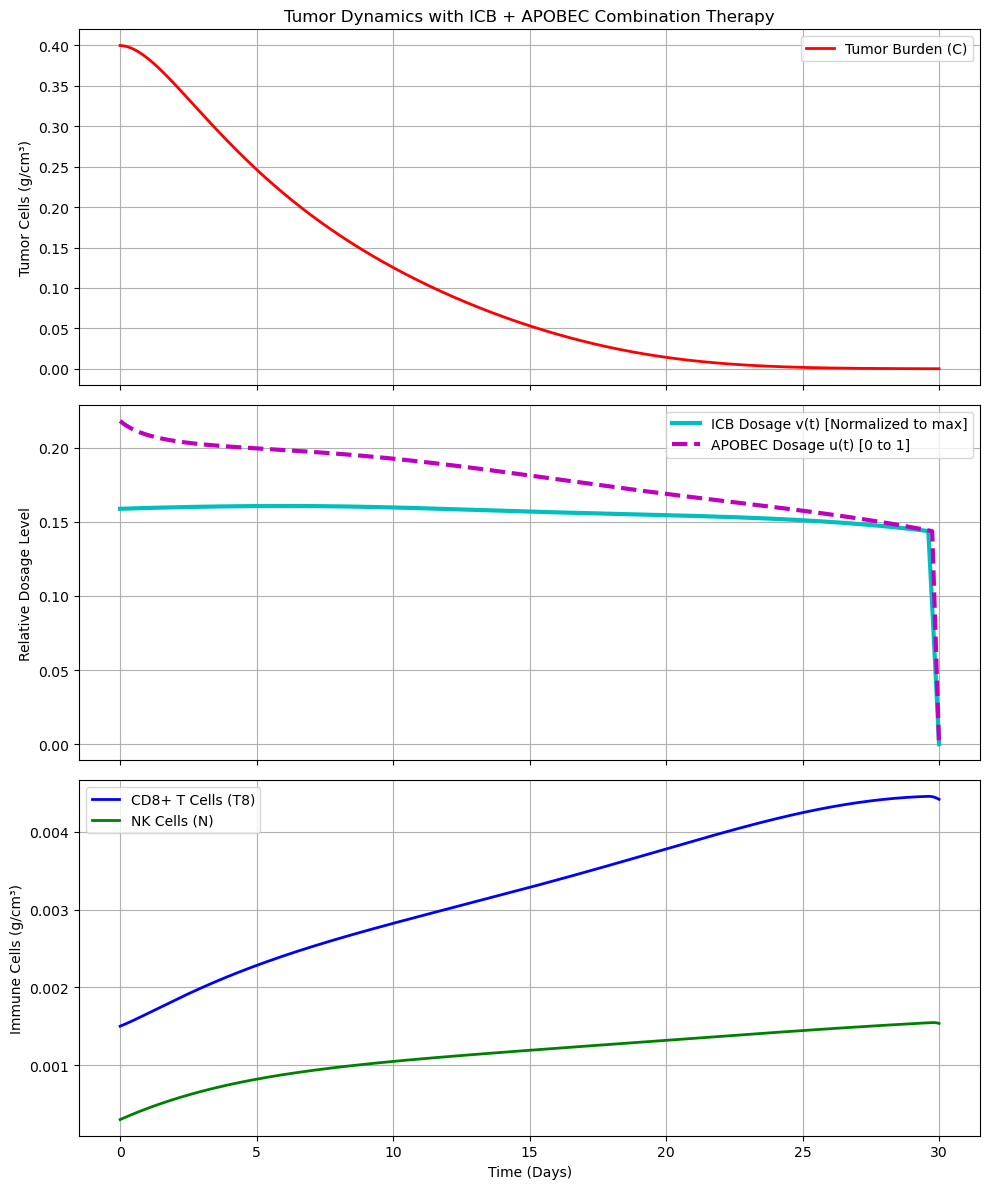

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (From Table 1 & 2)
# ==========================================
p = {
    # Tumor
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    
    # DCs
    "lambda_DC_comb": 0.00008,  # Calculated: lambda_DC (4) * D0 (2e-5)
    "K_C": 0.4, "d_D": 0.1,
    
    # NK cells
    "sigma_N": 0.00005,         # From Table 1
    "d_N": 0.1,                 # From Table 1
    "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    
    # Tregs
    "d_Treg": 0.2, 
    "lambda_Tr_comb": 0.0002,   # Calculated: lambda_Tr (0.5) * T10 (4e-4)
    
    # CD8 T cells
    "d_T8": 0.18,               # From Table 1
    "lambda_T8_comb": 0.00108,  # Calculated: lambda_T8 (5.4) * T80 (2e-4)
    "K_Treg": 2.5e-4,           # From Table 1
    "K_D": 4e-4
}

# APOBEC deltas (Target APOBEC Table - Table 1 Baseline)
d_p = {
    "d_lambda_DC": 0.003 - p["lambda_DC_comb"], # +0.00292
    "d_lambda_T8": 0.001 - p["lambda_T8_comb"], # -0.00008 (Slight decrease)
    "d_sigma_N": 0.0005 - p["sigma_N"]          # +0.00045
}

# Optimization weights 
a = 5000.0     # Penalty for CD8+ injection (v)
w = 0.001      # Penalty for APOBEC dosage (u) 
b = 0.0001     # Weight for tumor burden 
v_max = 0.0008 # Max ICB dose
u_max = 1.0    # Max APOBEC dose

T_final = 30.0       
N_steps = 20000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)

def get_eff_p(p_base, u_val):
    eff = p_base.copy()
    eff["lambda_DC_comb"] += u_val * d_p["d_lambda_DC"]
    eff["lambda_T8_comb"] += u_val * d_p["d_lambda_T8"]
    eff["sigma_N"]        += u_val * d_p["d_sigma_N"]
    return eff

# ==========================================
# 2. Dual-Control Derivatives
# ==========================================
def state_derivatives(x, v_val, u_val):
    C, D, N, Tr, T8 = x
    eff = get_eff_p(p, u_val)
    
    dC  = eff["lambda_C"]*C*(1 - C/eff["C_M"]) - eff["eta_8"]*T8*C - eff["eta_N"]*N*C - eff["d_C"]*C
    dD  = eff["lambda_DC_comb"] * C / (eff["K_C"] + C) - eff["d_D"]*D
    dN  = eff["sigma_N"] - eff["d_N"]*N - eff["gamma_N"]*Tr*N + eff["a_C"]*N*C / (1 + C/eff["beta_1"] + N/eff["beta_2"])
    dTr = -eff["d_Treg"]*Tr + eff["lambda_Tr_comb"] * C / (eff["K_C"] + C)
    dT8 = -eff["d_T8"]*T8 + eff["lambda_T8_comb"] * (D / (eff["K_D"] + D)) * (1 / (1 + Tr/eff["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, u_val):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    eff = get_eff_p(p, u_val)
    
    den_KC = eff["K_C"] + C
    den_NK = 1 + C/eff["beta_1"] + N/eff["beta_2"]
    den_KD = eff["K_D"] + D
    den_KTr = 1 + Tr/eff["K_Treg"]

    dl1 = -( b + l1*(eff["lambda_C"] - 2*eff["lambda_C"]*C/eff["C_M"] - eff["eta_8"]*T8 - eff["eta_N"]*N - eff["d_C"]) 
             + l2*(eff["lambda_DC_comb"] * eff["K_C"] / den_KC**2) 
             + l3*(eff["a_C"]*N*(1 + N/eff["beta_2"]) / den_NK**2) 
             + l4*(eff["lambda_Tr_comb"] * eff["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*eff["d_D"] + l5*(eff["lambda_T8_comb"] * (eff["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*eff["eta_N"]*C + l3*(-eff["d_N"] - eff["gamma_N"]*Tr + eff["a_C"]*C*(1 + C/eff["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*eff["gamma_N"]*N - l4*eff["d_Treg"] + l5*(eff["lambda_T8_comb"] * (D / den_KD) * (-1/eff["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*eff["eta_8"]*C - l5*eff["d_T8"] )
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Co-Optimization FBSM Loop
# ==========================================
x = np.zeros((5, N_steps))
lam = np.zeros((5, N_steps))
x[:, 0] = [0.4, 0.0004, 0.0003, 0.0005, 0.0015] # From Table 2

v = np.zeros(N_steps) # ICB Control
u = np.zeros(N_steps) # APOBEC Control

tolerance = 1e-4
max_iter = 500
test = tolerance + 1
iteration = 0

print("Starting Combination Therapy Co-Optimization...")

while test > tolerance and iteration < max_iter:
    old_v, old_u, old_x, old_lam = v.copy(), u.copy(), x.copy(), lam.copy()
    
    # FORWARD SWEEP
    for i in range(N_steps - 1):
        v_mid, u_mid = 0.5*(v[i] + v[i+1]), 0.5*(u[i] + u[i+1])
        current_x = np.maximum(x[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v[i], u[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid, u_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid, u_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1], u[i+1])
        
        x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
        
    # BACKWARD SWEEP
    lam[0, -1] = 1.0  
    lam[1:, -1] = 0.0 
    
    for i in range(N_steps - 1, 0, -1):
        x_mid = 0.5 * (x[:, i] + x[:, i-1])
        u_mid = 0.5 * (u[i] + u[i-1])
        
        k1 = dt * adjoint_derivatives(x[:, i], lam[:, i], u[i])
        k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, u_mid)
        k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, u_mid)
        k4 = dt * adjoint_derivatives(x[:, i-1], lam[:, i] - k3, u[i-1])
        
        lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
        
    # DUAL CONTROL UPDATE 
    v_new = np.zeros(N_steps)
    u_new = np.zeros(N_steps)
    
    for i in range(N_steps):
        C_val, D_val, N_val, Tr_val, T8_val = x[:, i]
        l1, l2, l3, l4, l5 = lam[:, i]
        
        # ICB (v) Update
        v_calc = -l5 / (2 * a)
        v_new[i] = max(0.0, min(v_max, v_calc))
        
        # APOBEC (u) Update 
        term1 = l2 * d_p["d_lambda_DC"] * (C_val / (p["K_C"] + C_val))
        term2 = l3 * d_p["d_sigma_N"]
        term3 = l5 * d_p["d_lambda_T8"] * (D_val / (p["K_D"] + D_val)) * (1 / (1 + Tr_val/p["K_Treg"]))
        
        u_calc = -(term1 + term2 + term3) / (2 * w)
        u_new[i] = max(0.0, min(u_max, u_calc))
        
    # CONVEX COMBINATION 
    v = 0.5 * v_new + 0.5 * old_v
    u = 0.5 * u_new + 0.5 * old_u
    
    test = (np.sum(np.abs(v - old_v)) / (np.sum(np.abs(v)) + 1e-10) +
            np.sum(np.abs(u - old_u)) / (np.sum(np.abs(u)) + 1e-10) +
            np.sum(np.abs(x - old_x)) / (np.sum(np.abs(x)) + 1e-10) +
            np.sum(np.abs(lam - old_lam)) / (np.sum(np.abs(lam)) + 1e-10))
    iteration += 1
    
    if iteration % 10 == 0:
        print(f"Iteration {iteration}, Error: {test:.5f}")

print(f"Converged in {iteration} iterations.")

# ==========================================
# 4. Plotting
# ==========================================
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Tumor
axs[0].plot(t, x[0, :], 'r-', linewidth=2, label='Tumor Burden (C)')
axs[0].set_ylabel('Tumor Cells (g/cm³)')
axs[0].set_title('Tumor Dynamics with ICB + APOBEC Combination Therapy')
axs[0].legend()
axs[0].grid(True)

# Drugs
axs[1].plot(t, v / v_max, 'c-', linewidth=3, label='ICB Dosage v(t) [Normalized to max]')
axs[1].plot(t, u, 'm--', linewidth=3, label='APOBEC Dosage u(t) [0 to 1]')
axs[1].set_ylabel('Relative Dosage Level')
axs[1].legend()
axs[1].grid(True)

# Immune
axs[2].plot(t, x[4, :], 'b-', linewidth=2, label='CD8+ T Cells (T8)')
axs[2].plot(t, x[2, :], 'g-', linewidth=2, label='NK Cells (N)')
axs[2].set_xlabel('Time (Days)')
axs[2].set_ylabel('Immune Cells (g/cm³)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

Sweeping parameter 'a' (ICB Penalty)...
Sweeping parameter 'w' (APOBEC Penalty)...
Plotting...


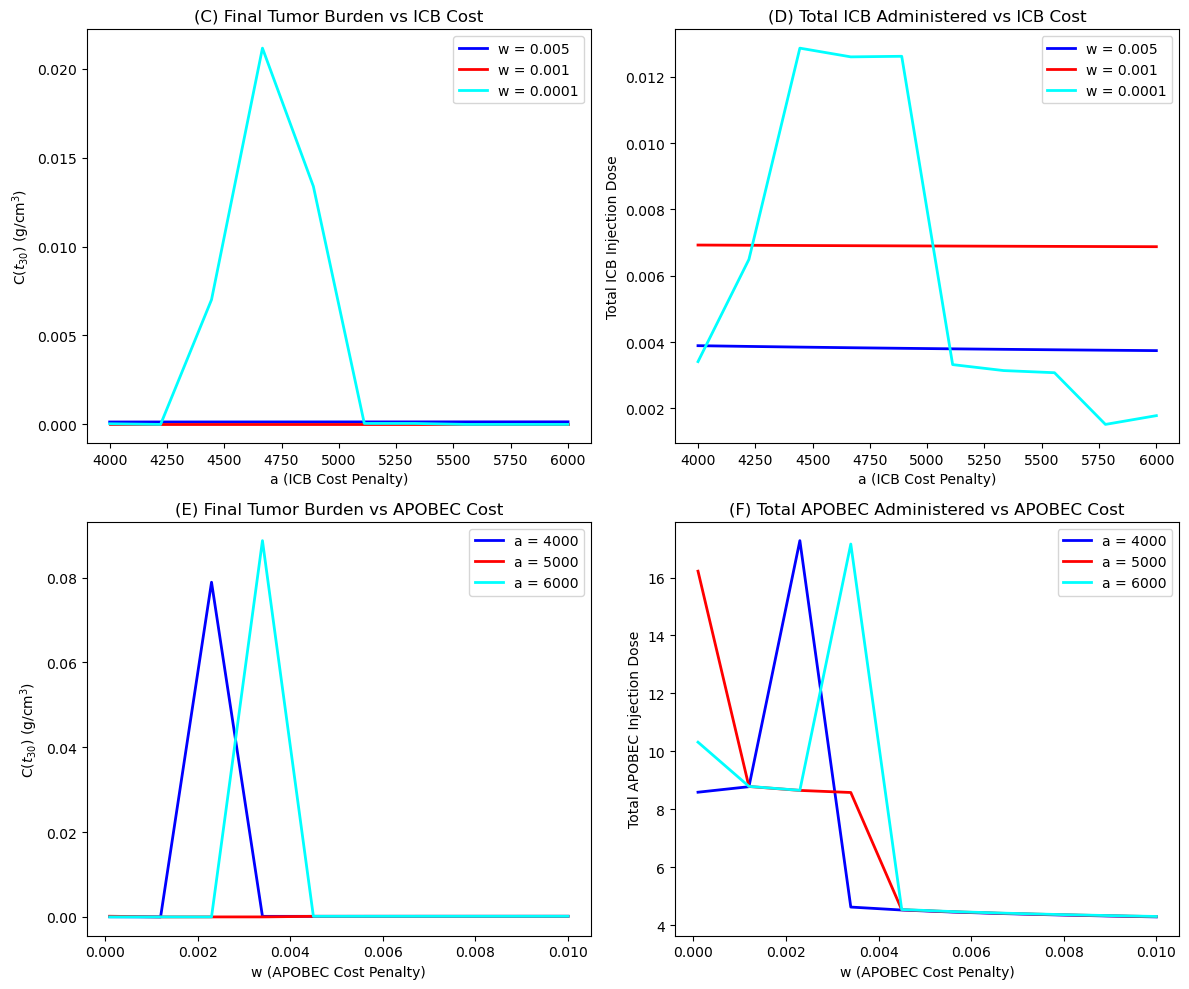

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (From your code)
# ==========================================
p = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    "lambda_DC_comb": 0.00008,  
    "K_C": 0.4, "d_D": 0.1,
    "sigma_N": 0.00005,         
    "d_N": 0.1,                 
    "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    "d_Treg": 0.2, 
    "lambda_Tr_comb": 0.0002,   
    "d_T8": 0.18,               
    "lambda_T8_comb": 0.00108,  
    "K_Treg": 2.5e-4,           
    "K_D": 4e-4
}

d_p = {
    "d_lambda_DC": 0.003 - p["lambda_DC_comb"], 
    "d_lambda_T8": 0.001 - p["lambda_T8_comb"], 
    "d_sigma_N": 0.0005 - p["sigma_N"]          
}

T_final = 30.0       
N_steps = 1000 # Reduced for the grid search speed
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)
x0 = [0.4, 0.0004, 0.0003, 0.0005, 0.0015]

v_max = 0.0008
u_max = 1.0    

def get_eff_p(p_base, u_val):
    eff = p_base.copy()
    eff["lambda_DC_comb"] += u_val * d_p["d_lambda_DC"]
    eff["lambda_T8_comb"] += u_val * d_p["d_lambda_T8"]
    eff["sigma_N"]        += u_val * d_p["d_sigma_N"]
    return eff

# ==========================================
# 2. Derivative Functions
# ==========================================
def state_derivatives(x, v_val, u_val):
    C, D, N, Tr, T8 = x
    eff = get_eff_p(p, u_val)
    
    dC  = eff["lambda_C"]*C*(1 - C/eff["C_M"]) - eff["eta_8"]*T8*C - eff["eta_N"]*N*C - eff["d_C"]*C
    dD  = eff["lambda_DC_comb"] * C / (eff["K_C"] + C) - eff["d_D"]*D
    dN  = eff["sigma_N"] - eff["d_N"]*N - eff["gamma_N"]*Tr*N + eff["a_C"]*N*C / (1 + C/eff["beta_1"] + N/eff["beta_2"])
    dTr = -eff["d_Treg"]*Tr + eff["lambda_Tr_comb"] * C / (eff["K_C"] + C)
    dT8 = -eff["d_T8"]*T8 + eff["lambda_T8_comb"] * (D / (eff["K_D"] + D)) * (1 / (1 + Tr/eff["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, u_val, b_weight):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    eff = get_eff_p(p, u_val)
    
    den_KC = eff["K_C"] + C
    den_NK = 1 + C/eff["beta_1"] + N/eff["beta_2"]
    den_KD = eff["K_D"] + D
    den_KTr = 1 + Tr/eff["K_Treg"]

    dl1 = -( b_weight + l1*(eff["lambda_C"] - 2*eff["lambda_C"]*C/eff["C_M"] - eff["eta_8"]*T8 - eff["eta_N"]*N - eff["d_C"]) 
             + l2*(eff["lambda_DC_comb"] * eff["K_C"] / den_KC**2) 
             + l3*(eff["a_C"]*N*(1 + N/eff["beta_2"]) / den_NK**2) 
             + l4*(eff["lambda_Tr_comb"] * eff["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*eff["d_D"] + l5*(eff["lambda_T8_comb"] * (eff["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*eff["eta_N"]*C + l3*(-eff["d_N"] - eff["gamma_N"]*Tr + eff["a_C"]*C*(1 + C/eff["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*eff["gamma_N"]*N - l4*eff["d_Treg"] + l5*(eff["lambda_T8_comb"] * (D / den_KD) * (-1/eff["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*eff["eta_8"]*C - l5*eff["d_T8"] )
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Optimization Wrapper Function
# ==========================================
def solve_dual_control(a_weight, w_weight, b_weight, max_iter=250, tolerance=1e-3):
    """Runs your specific FBSM for given penalties a and w."""
    x = np.zeros((5, N_steps))
    lam = np.zeros((5, N_steps))
    x[:, 0] = x0

    v = np.zeros(N_steps)
    u = np.zeros(N_steps)

    test = tolerance + 1
    iteration = 0

    while test > tolerance and iteration < max_iter:
        old_v, old_u, old_x, old_lam = v.copy(), u.copy(), x.copy(), lam.copy()
        
        # FORWARD SWEEP
        for i in range(N_steps - 1):
            v_mid, u_mid = 0.5*(v[i] + v[i+1]), 0.5*(u[i] + u[i+1])
            current_x = np.maximum(x[:, i], 0.0)
            
            k1 = dt * state_derivatives(current_x, v[i], u[i])
            k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid, u_mid)
            k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid, u_mid)
            k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1], u[i+1])
            
            x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
            
        # BACKWARD SWEEP
        lam[0, -1] = 1.0  
        lam[1:, -1] = 0.0 
        
        for i in range(N_steps - 1, 0, -1):
            x_mid = 0.5 * (x[:, i] + x[:, i-1])
            u_mid = 0.5 * (u[i] + u[i-1])
            
            k1 = dt * adjoint_derivatives(x[:, i], lam[:, i], u[i], b_weight)
            k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, u_mid, b_weight)
            k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, u_mid, b_weight)
            k4 = dt * adjoint_derivatives(x[:, i-1], lam[:, i] - k3, u[i-1], b_weight)
            
            lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
            
        # DUAL CONTROL UPDATE 
        v_new = np.zeros(N_steps)
        u_new = np.zeros(N_steps)
        
        for i in range(N_steps):
            C_val, D_val, N_val, Tr_val, T8_val = x[:, i]
            l1, l2, l3, l4, l5 = lam[:, i]
            
            # ICB (v) Update
            v_calc = -l5 / (2 * a_weight)
            v_new[i] = max(0.0, min(v_max, v_calc))
            
            # APOBEC (u) Update 
            term1 = l2 * d_p["d_lambda_DC"] * (C_val / (p["K_C"] + C_val))
            term2 = l3 * d_p["d_sigma_N"]
            term3 = l5 * d_p["d_lambda_T8"] * (D_val / (p["K_D"] + D_val)) * (1 / (1 + Tr_val/p["K_Treg"]))
            
            u_calc = -(term1 + term2 + term3) / (2 * w_weight)
            u_new[i] = max(0.0, min(u_max, u_calc))
            
        # CONVEX COMBINATION 
        v = 0.5 * v_new + 0.5 * old_v
        u = 0.5 * u_new + 0.5 * old_u
        
        diff_v = np.sum(np.abs(v - old_v)) / (np.sum(np.abs(v)) + 1e-10)
        diff_u = np.sum(np.abs(u - old_u)) / (np.sum(np.abs(u)) + 1e-10)
        test = diff_v + diff_u
        iteration += 1

    return x[0, -1], np.sum(v) * dt, np.sum(u) * dt

# ==========================================
# 4. Generating the Data (Sweeping 'a' and 'w')
# ==========================================
num_points = 10 # Increase to 30+ for smoother final lines

b_fixed = 0.0001
w_fixed_list = [0.005, 0.001, 0.0001] # Different penalties for APOBEC
a_range = np.linspace(4000, 6000, num_points)

print("Sweeping parameter 'a' (ICB Penalty)...")
res_C_a = {w: [] for w in w_fixed_list}
res_V_a = {w: [] for w in w_fixed_list}

for w in w_fixed_list:
    for a in a_range:
        c30, dose_v, _ = solve_dual_control(a, w, b_fixed)
        res_C_a[w].append(c30)
        res_V_a[w].append(dose_v)

a_fixed_list = [4000, 5000, 6000] # Different penalties for ICB
w_range = np.linspace(0.0001, 0.01, num_points) 

print("Sweeping parameter 'w' (APOBEC Penalty)...")
res_C_w = {a: [] for a in a_fixed_list}
res_U_w = {a: [] for a in a_fixed_list}

for a in a_fixed_list:
    for w in w_range:
        c30, _, dose_u = solve_dual_control(a, w, b_fixed)
        res_C_w[a].append(c30)
        res_U_w[a].append(dose_u)

print("Plotting...")

# ==========================================
# 5. Plotting the 4 Graphs
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
colors = {0: 'blue', 1: 'red', 2: 'cyan'}

# Graph C: C(t30) vs a
for i, w in enumerate(w_fixed_list):
    axs[0, 0].plot(a_range, res_C_a[w], color=colors[i], linewidth=2, label=f'w = {w}')
axs[0, 0].set_xlabel('a (ICB Cost Penalty)')
axs[0, 0].set_ylabel('C($t_{30}$) (g/cm$^3$)')
axs[0, 0].set_title('(C) Final Tumor Burden vs ICB Cost')
axs[0, 0].legend()

# Graph D: Total Dose v vs a
for i, w in enumerate(w_fixed_list):
    axs[0, 1].plot(a_range, res_V_a[w], color=colors[i], linewidth=2, label=f'w = {w}')
axs[0, 1].set_xlabel('a (ICB Cost Penalty)')
axs[0, 1].set_ylabel('Total ICB Injection Dose')
axs[0, 1].set_title('(D) Total ICB Administered vs ICB Cost')
axs[0, 1].legend()

# Graph E: C(t30) vs w
for i, a in enumerate(a_fixed_list):
    axs[1, 0].plot(w_range, res_C_w[a], color=colors[i], linewidth=2, label=f'a = {a}')
axs[1, 0].set_xlabel('w (APOBEC Cost Penalty)')
axs[1, 0].set_ylabel('C($t_{30}$) (g/cm$^3$)')
axs[1, 0].set_title('(E) Final Tumor Burden vs APOBEC Cost')
axs[1, 0].legend()

# Graph F: Total Dose u vs w
for i, a in enumerate(a_fixed_list):
    axs[1, 1].plot(w_range, res_U_w[a], color=colors[i], linewidth=2, label=f'a = {a}')
axs[1, 1].set_xlabel('w (APOBEC Cost Penalty)')
axs[1, 1].set_ylabel('Total APOBEC Injection Dose')
axs[1, 1].set_title('(F) Total APOBEC Administered vs APOBEC Cost')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

Running baseline co-optimization for time-series plots...


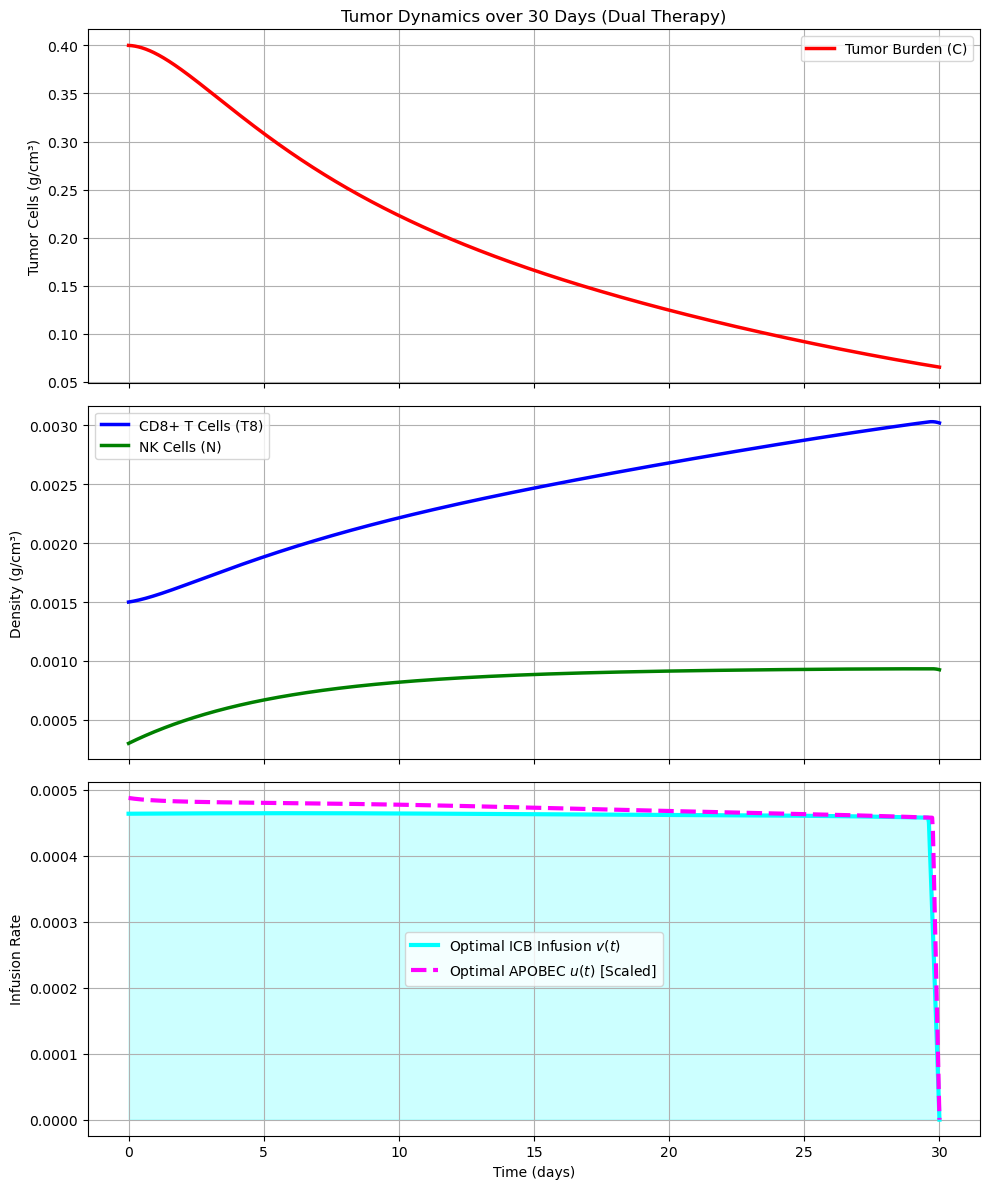

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters
# ==========================================
p = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    "lambda_DC_comb": 0.00008,  
    "K_C": 0.4, "d_D": 0.1,
    "sigma_N": 0.00005,         
    "d_N": 0.1,                 
    "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    "d_Treg": 0.2, 
    "lambda_Tr_comb": 0.0002,   
    "d_T8": 0.18,               
    "lambda_T8_comb": 0.00108,  
    "K_Treg": 2.5e-4,           
    "K_D": 4e-4
}

d_p = {
    "d_lambda_DC": 0.003 - p["lambda_DC_comb"], 
    "d_lambda_T8": 0.001 - p["lambda_T8_comb"], 
    "d_sigma_N": 0.0005 - p["sigma_N"]          
}

T_final = 30.0       
N_steps = 1000  # 1000 is optimal for balancing grid-search speed and precision
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)
x0 = [0.4, 0.0004, 0.0003, 0.0005, 0.0015]

v_max = 0.0008
u_max = 1.0    

def get_eff_p(p_base, u_val):
    eff = p_base.copy()
    eff["lambda_DC_comb"] += u_val * d_p["d_lambda_DC"]
    eff["lambda_T8_comb"] += u_val * d_p["d_lambda_T8"]
    eff["sigma_N"]        += u_val * d_p["d_sigma_N"]
    return eff

# ==========================================
# 2. Derivative Functions
# ==========================================
def state_derivatives(x, v_val, u_val):
    C, D, N, Tr, T8 = x
    eff = get_eff_p(p, u_val)
    
    dC  = eff["lambda_C"]*C*(1 - C/eff["C_M"]) - eff["eta_8"]*T8*C - eff["eta_N"]*N*C - eff["d_C"]*C
    dD  = eff["lambda_DC_comb"] * C / (eff["K_C"] + C) - eff["d_D"]*D
    dN  = eff["sigma_N"] - eff["d_N"]*N - eff["gamma_N"]*Tr*N + eff["a_C"]*N*C / (1 + C/eff["beta_1"] + N/eff["beta_2"])
    dTr = -eff["d_Treg"]*Tr + eff["lambda_Tr_comb"] * C / (eff["K_C"] + C)
    dT8 = -eff["d_T8"]*T8 + eff["lambda_T8_comb"] * (D / (eff["K_D"] + D)) * (1 / (1 + Tr/eff["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, u_val, b_weight):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    eff = get_eff_p(p, u_val)
    
    den_KC = eff["K_C"] + C
    den_NK = 1 + C/eff["beta_1"] + N/eff["beta_2"]
    den_KD = eff["K_D"] + D
    den_KTr = 1 + Tr/eff["K_Treg"]

    dl1 = -( b_weight + l1*(eff["lambda_C"] - 2*eff["lambda_C"]*C/eff["C_M"] - eff["eta_8"]*T8 - eff["eta_N"]*N - eff["d_C"]) 
             + l2*(eff["lambda_DC_comb"] * eff["K_C"] / den_KC**2) 
             + l3*(eff["a_C"]*N*(1 + N/eff["beta_2"]) / den_NK**2) 
             + l4*(eff["lambda_Tr_comb"] * eff["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*eff["d_D"] + l5*(eff["lambda_T8_comb"] * (eff["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*eff["eta_N"]*C + l3*(-eff["d_N"] - eff["gamma_N"]*Tr + eff["a_C"]*C*(1 + C/eff["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*eff["gamma_N"]*N - l4*eff["d_Treg"] + l5*(eff["lambda_T8_comb"] * (D / den_KD) * (-1/eff["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*eff["eta_8"]*C - l5*eff["d_T8"] )
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. FBSM Wrapper
# ==========================================
def solve_dual_control(a_weight, w_weight, b_weight, max_iter=300, tolerance=1e-4):
    x = np.zeros((5, N_steps))
    lam = np.zeros((5, N_steps))
    x[:, 0] = x0

    v = np.zeros(N_steps)
    u = np.zeros(N_steps)

    test = tolerance + 1
    iteration = 0

    while test > tolerance and iteration < max_iter:
        old_v, old_u, old_x, old_lam = v.copy(), u.copy(), x.copy(), lam.copy()
        
        # FORWARD SWEEP
        for i in range(N_steps - 1):
            v_mid, u_mid = 0.5*(v[i] + v[i+1]), 0.5*(u[i] + u[i+1])
            current_x = np.maximum(x[:, i], 0.0)
            
            k1 = dt * state_derivatives(current_x, v[i], u[i])
            k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid, u_mid)
            k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid, u_mid)
            k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1], u[i+1])
            
            x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
            
        # BACKWARD SWEEP
        lam[0, -1] = 1.0  
        lam[1:, -1] = 0.0 
        
        for i in range(N_steps - 1, 0, -1):
            x_mid = 0.5 * (x[:, i] + x[:, i-1])
            u_mid = 0.5 * (u[i] + u[i-1])
            
            k1 = dt * adjoint_derivatives(x[:, i], lam[:, i], u[i], b_weight)
            k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, u_mid, b_weight)
            k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, u_mid, b_weight)
            k4 = dt * adjoint_derivatives(x[:, i-1], lam[:, i] - k3, u[i-1], b_weight)
            
            lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
            
        # CONTROL UPDATES
        v_new = np.zeros(N_steps)
        u_new = np.zeros(N_steps)
        
        for i in range(N_steps):
            C_val, D_val, N_val, Tr_val, T8_val = x[:, i]
            l1, l2, l3, l4, l5 = lam[:, i]
            
            # ICB (v) Update
            v_calc = -l5 / (2 * a_weight)
            v_new[i] = max(0.0, min(v_max, v_calc))
            
            # APOBEC (u) Update 
            term1 = l2 * d_p["d_lambda_DC"] * (C_val / (p["K_C"] + C_val))
            term2 = l3 * d_p["d_sigma_N"]
            term3 = l5 * d_p["d_lambda_T8"] * (D_val / (p["K_D"] + D_val)) * (1 / (1 + Tr_val/p["K_Treg"]))
            
            u_calc = -(term1 + term2 + term3) / (2 * w_weight)
            u_new[i] = max(0.0, min(u_max, u_calc))
            
        # CONVEX COMBINATION 
        v = 0.5 * v_new + 0.5 * old_v
        u = 0.5 * u_new + 0.5 * old_u
        
        diff_v = np.sum(np.abs(v - old_v)) / (np.sum(np.abs(v)) + 1e-10)
        diff_u = np.sum(np.abs(u - old_u)) / (np.sum(np.abs(u)) + 1e-10)
        test = diff_v + diff_u
        iteration += 1

    return x, v, u, x[0, -1], np.sum(v) * dt, np.sum(u) * dt


# ==========================================
# 4. Generate the 3-Panel Baseline Plot
# ==========================================
print("Running baseline co-optimization for time-series plots...")
a_base = 5000.0
w_base = 0.001
b_base = 0.0001
x_base, v_base, u_base, c30_base, _, _ = solve_dual_control(a_base, w_base, b_base)

fig1, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Top: Tumor Burden
axs[0].plot(t, x_base[0, :], 'r-', linewidth=2.5, label='Tumor Burden (C)')
axs[0].set_ylabel('Tumor Cells (g/cm³)')
axs[0].set_title('Tumor Dynamics over 30 Days (Dual Therapy)')
axs[0].grid(True)
axs[0].legend()

# Middle: Immune Cells
axs[1].plot(t, x_base[4, :], 'b-', linewidth=2.5, label='CD8+ T Cells (T8)')
axs[1].plot(t, x_base[2, :], 'g-', linewidth=2.5, label='NK Cells (N)')
axs[1].set_ylabel('Density (g/cm³)')
axs[1].grid(True)
axs[1].legend()

# Bottom: Treatments
axs[2].plot(t, v_base, color='cyan', linewidth=3, label='Optimal ICB Infusion $v(t)$')
axs[2].plot(t, u_base * (v_max/u_max), color='magenta', linestyle='--', linewidth=3, label='Optimal APOBEC $u(t)$ [Scaled]')
axs[2].fill_between(t, v_base, color='cyan', alpha=0.2)
axs[2].set_xlabel('Time (days)')
axs[2].set_ylabel('Infusion Rate')
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()



In [ ]:
# ==========================================
# 5. Generate the 4 Sensitivity Plots
# ==========================================
print("Running parameter sweeps for sensitivity graphs (This will take a moment)...")

num_points = 15 # Grid resolution

# Sweep 1: Varying ICB penalty 'a'
w_fixed_list = [0.005, 0.001, 0.0001] 
a_range = np.linspace(4000, 6000, num_points)

res_C_a = {w: [] for w in w_fixed_list}
res_V_a = {w: [] for w in w_fixed_list}

for w in w_fixed_list:
    for a in a_range:
        _, _, _, c30, dose_v, _ = solve_dual_control(a, w, b_base)
        res_C_a[w].append(c30)
        res_V_a[w].append(dose_v)

# Sweep 2: Varying APOBEC penalty 'w'
a_fixed_list = [4000, 5000, 6000] 
w_range = np.linspace(0.0001, 0.01, num_points) 

res_C_w = {a: [] for a in a_fixed_list}
res_U_w = {a: [] for a in a_fixed_list}

for a in a_fixed_list:
    for w in w_range:
        _, _, _, c30, _, dose_u = solve_dual_control(a, w, b_base)
        res_C_w[a].append(c30)
        res_U_w[a].append(dose_u)

# Plotting the 4 sensitivity graphs
fig2, axs2 = plt.subplots(2, 2, figsize=(14, 10))
colors = {0: 'blue', 1: 'red', 2: 'cyan'}

# Graph C
for i, w in enumerate(w_fixed_list):
    axs2[0, 0].plot(a_range, res_C_a[w], color=colors[i], linewidth=2, label=f'w = {w}')
axs2[0, 0].set_xlabel('a (cm³ · day/g) [ICB Penalty]')
axs2[0, 0].set_ylabel('$C(t_{30})$ (g/cm³)')
axs2[0, 0].set_title('(C) Final Tumor Burden vs ICB Penalty')
axs2[0, 0].legend()

# Graph D
for i, w in enumerate(w_fixed_list):
    axs2[0, 1].plot(a_range, res_V_a[w], color=colors[i], linewidth=2, label=f'w = {w}')
axs2[0, 1].set_xlabel('a (cm³ · day/g) [ICB Penalty]')
axs2[0, 1].set_ylabel('Total ICB Injection Dose (g/cm³)')
axs2[0, 1].set_title('(D) Total ICB Dose vs ICB Penalty')
axs2[0, 1].legend()

# Graph E
for i, a in enumerate(a_fixed_list):
    axs2[1, 0].plot(w_range, res_C_w[a], color=colors[i], linewidth=2, label=f'a = {a}')
axs2[1, 0].set_xlabel('w [APOBEC Penalty]')
axs2[1, 0].set_ylabel('$C(t_{30})$ (g/cm³)')
axs2[1, 0].set_title('(E) Final Tumor Burden vs APOBEC Penalty')
axs2[1, 0].legend()

# Graph F
for i, a in enumerate(a_fixed_list):
    axs2[1, 1].plot(w_range, res_U_w[a], color=colors[i], linewidth=2, label=f'a = {a}')
axs2[1, 1].set_xlabel('w [APOBEC Penalty]')
axs2[1, 1].set_ylabel('Total APOBEC Injection Dose (g/cm³)')
axs2[1, 1].set_title('(F) Total APOBEC Dose vs APOBEC Penalty')
axs2[1, 1].legend()

plt.tight_layout()
plt.show()